In [2]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
#Loading Dataset 
train = pd.read_csv('../data/sent_train.csv')
valid = pd.read_csv('../data/sent_valid.csv')

print("TRAIN DATASET")
print("Shape     :", train.shape)
print("Columns   :", train.columns.tolist())
print()
print("VALID DATASET")
print("Shape     :", valid.shape)
print("Columns   :", valid.columns.tolist())

TRAIN DATASET
Shape     : (9543, 2)
Columns   : ['text', 'label']

VALID DATASET
Shape     : (2388, 2)
Columns   : ['text', 'label']


In [4]:
print("TRAIN - First 5 rows:")
print(train.head())
print()
print("VALID - First 5 rows:")
print(valid.head())
print()
print("TRAIN - Data Types:")
print(train.dtypes)
print()
print("VALID - Data Types:")
print(valid.dtypes)

TRAIN - First 5 rows:
                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
3  $ESS: BTIG Research cuts to Neutral https://t....      0
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0

VALID - First 5 rows:
                                                text  label
0  $ALLY - Ally Financial pulls outlook https://t...      0
1  $DELL $HPE - Dell, HPE targets trimmed on comp...      0
2  $PRTY - Moody's turns negative on Party City h...      0
3                   $SAN: Deutsche Bank cuts to Hold      0
4                  $SITC: Compass Point cuts to Sell      0

TRAIN - Data Types:
text     object
label     int64
dtype: object

VALID - Data Types:
text     object
label     int64
dtype: object


In [5]:
print("TRAIN - Null Values:")
print(train.isnull().sum())
print()
print("VALID - Null Values:")
print(valid.isnull().sum())
print()

# Duplicates within train
train_dups = train.duplicated(subset='text').sum()
valid_dups = valid.duplicated(subset='text').sum()

# leakage check
merged = pd.merge(train, valid, on='text', how='inner')
print(f"Duplicate texts in Train     : {train_dups}")
print(f"Duplicate texts in Valid     : {valid_dups}")
print(f"Text overlap (Train & Valid) : {len(merged)} rows")

if len(merged) == 0:
    print("✓ No data leakage between train and validation splits.")
else:
    print("⚠ WARNING: Data leakage detected. These texts appear in both splits.")
    print(merged['text'].tolist())

TRAIN - Null Values:
text     0
label    0
dtype: int64

VALID - Null Values:
text     0
label    0
dtype: int64

Duplicate texts in Train     : 0
Duplicate texts in Valid     : 0
Text overlap (Train & Valid) : 0 rows
✓ No data leakage between train and validation splits.


TRAIN - Class Distribution:
  Neutral    :  6178  (64.7%)
  Bullish    :  1923  (20.2%)
  Bearish    :  1442  (15.1%)

VALID - Class Distribution:
  Neutral    :  1566  (65.6%)
  Bullish    :   475  (19.9%)
  Bearish    :   347  (14.5%)


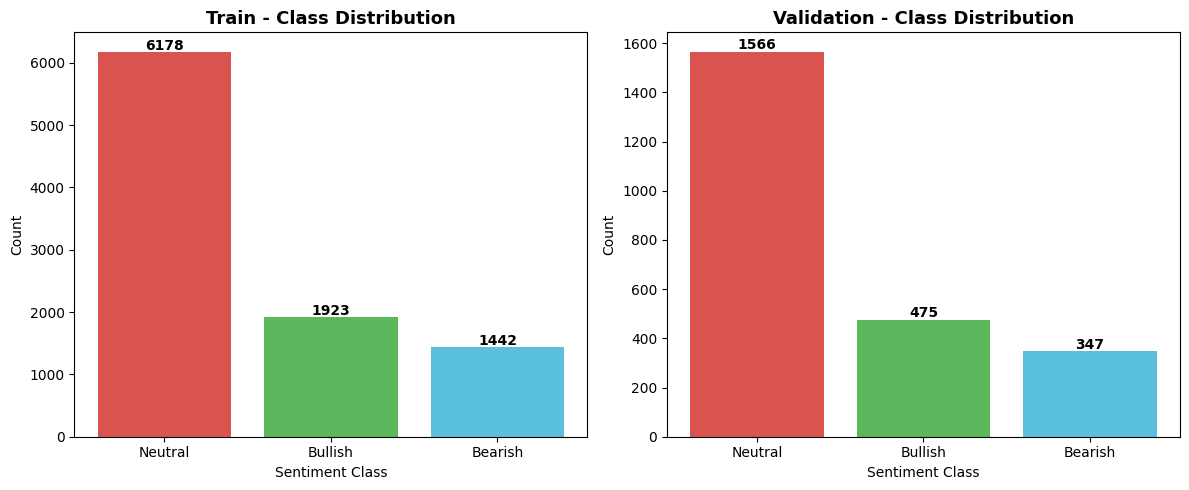

✓ Plot saved to assets/class_distribution.png


In [6]:
# Class Distribution
label_map = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}

train['label_name'] = train['label'].map(label_map)
valid['label_name'] = valid['label'].map(label_map)

train_dist = train['label_name'].value_counts()
valid_dist = valid['label_name'].value_counts()

print("TRAIN - Class Distribution:")
for label, count in train_dist.items():
    pct = count / len(train) * 100
    print(f"  {label:<10} : {count:>5}  ({pct:.1f}%)")

print()
print("VALID - Class Distribution:")
for label, count in valid_dist.items():
    pct = count / len(valid) * 100
    print(f"  {label:<10} : {count:>5}  ({pct:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#d9534f', '#5cb85c', '#5bc0de']

axes[0].bar(train_dist.index, train_dist.values, color=colors)
axes[0].set_title('Train - Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_dist.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].bar(valid_dist.index, valid_dist.values, color=colors)
axes[1].set_title('Validation - Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(valid_dist.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/class_distribution.png")

In [7]:
# Sample Tweets Per Class 
label_map = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}

for label_id, label_name in label_map.items():
    print(f"{'='*60}")
    print(f"  {label_name} (Label {label_id}) — 3 Sample Tweets")
    print(f"{'='*60}")
    samples = train[train['label'] == label_id]['text'].sample(3, random_state=42).tolist()
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s}")
    print()

  Bearish (Label 0) — 3 Sample Tweets
  1. Why These Top Oil Stocks All Tumbled More Than 10% in January
  2. Turkish lira weakens past key 6-per-dollar level
  3. Norsk Hydro reports lower Q4 earnings on weak aluminum prices

  Bullish (Label 1) — 3 Sample Tweets
  1. $CHFS big buyers here. Might bounce before the close.
  2. $FIZZ - National Beverage +4% as analysts keep scrambling https://t.co/JoctxfxaLB
  3. Genpact beat estimates in Q4

  Neutral (Label 2) — 3 Sample Tweets
  1. (Free to read) Over 60% of Americans say that stock market performance has little or no impact on their personal fi… https://t.co/l3QZQ3KwJy
  2. Best Buy has dodged death, but for how long? Watch the full video here to see how Best Buy has survived the retail… https://t.co/fvVyAzsL94
  3. How Good Is CENTROTEC Sustainable AG (ETR:CEV), When It Comes To ROE?



TRAIN - Word Count Stats:
             count   mean   std  min  25%   50%   75%   max
label_name                                                 
Bearish     1442.0  12.00  4.31  3.0  9.0  11.0  15.0  32.0
Bullish     1923.0  11.93  4.32  2.0  9.0  11.0  14.0  29.0
Neutral     6178.0  12.30  4.84  1.0  9.0  12.0  16.0  29.0

VALID - Word Count Stats:
             count   mean   std  min  25%   50%   75%   max
label_name                                                 
Bearish      347.0  11.73  4.40  3.0  9.0  11.0  15.0  29.0
Bullish      475.0  12.39  4.40  3.0  9.0  12.0  15.0  33.0
Neutral     1566.0  12.43  4.88  1.0  9.0  12.0  16.0  27.0

TRAIN - Overall Word Count:
  Min    : 1
  Max    : 32
  Mean   : 12.2
  Median : 11.0
  95th % : 21  ← use this for max sequence length


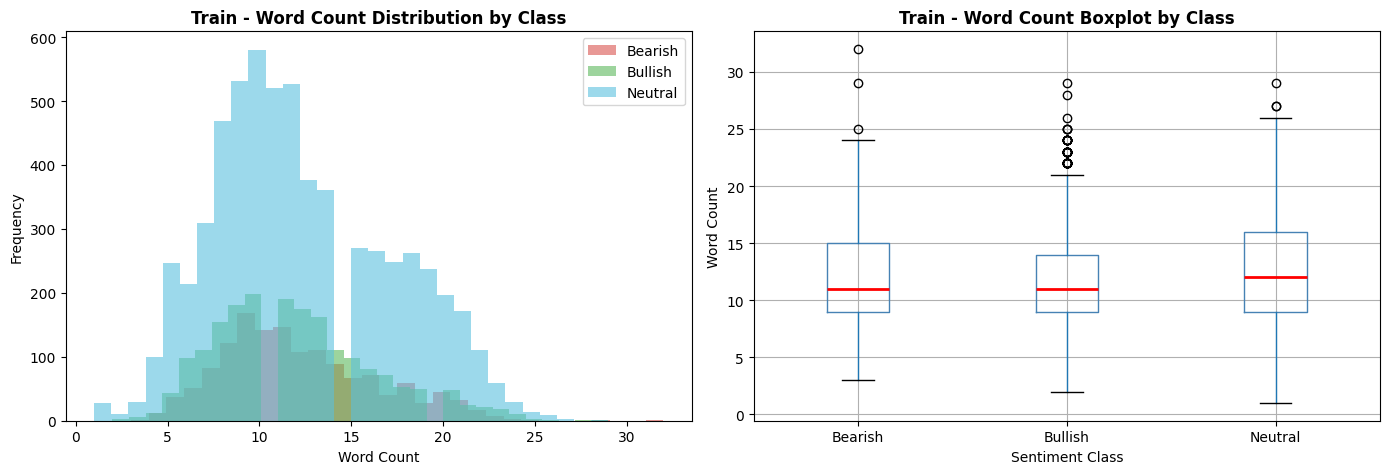

✓ Plot saved to assets/tweet_length_distribution.png


In [8]:
# Tweet Length Analysis
train['word_count'] = train['text'].apply(lambda x: len(x.split()))
train['char_count'] = train['text'].apply(lambda x: len(x))

valid['word_count'] = valid['text'].apply(lambda x: len(x.split()))
valid['char_count'] = valid['text'].apply(lambda x: len(x))

print("TRAIN - Word Count Stats:")
print(train.groupby('label_name')['word_count'].describe().round(2))
print()
print("VALID - Word Count Stats:")
print(valid.groupby('label_name')['word_count'].describe().round(2))
print()
print("TRAIN - Overall Word Count:")
print(f"  Min    : {train['word_count'].min()}")
print(f"  Max    : {train['word_count'].max()}")
print(f"  Mean   : {train['word_count'].mean():.1f}")
print(f"  Median : {train['word_count'].median()}")
print(f"  95th % : {train['word_count'].quantile(0.95):.0f}  ← use this for max sequence length")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label_id, label_name, color in zip([0,1,2], ['Bearish','Bullish','Neutral'], ['#d9534f','#5cb85c','#5bc0de']):
    subset = train[train['label'] == label_id]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label_name, color=color)

axes[0].set_title('Train - Word Count Distribution by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

train.boxplot(column='word_count', by='label_name', ax=axes[1],
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Train - Word Count Boxplot by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../assets/tweet_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/tweet_length_distribution.png")

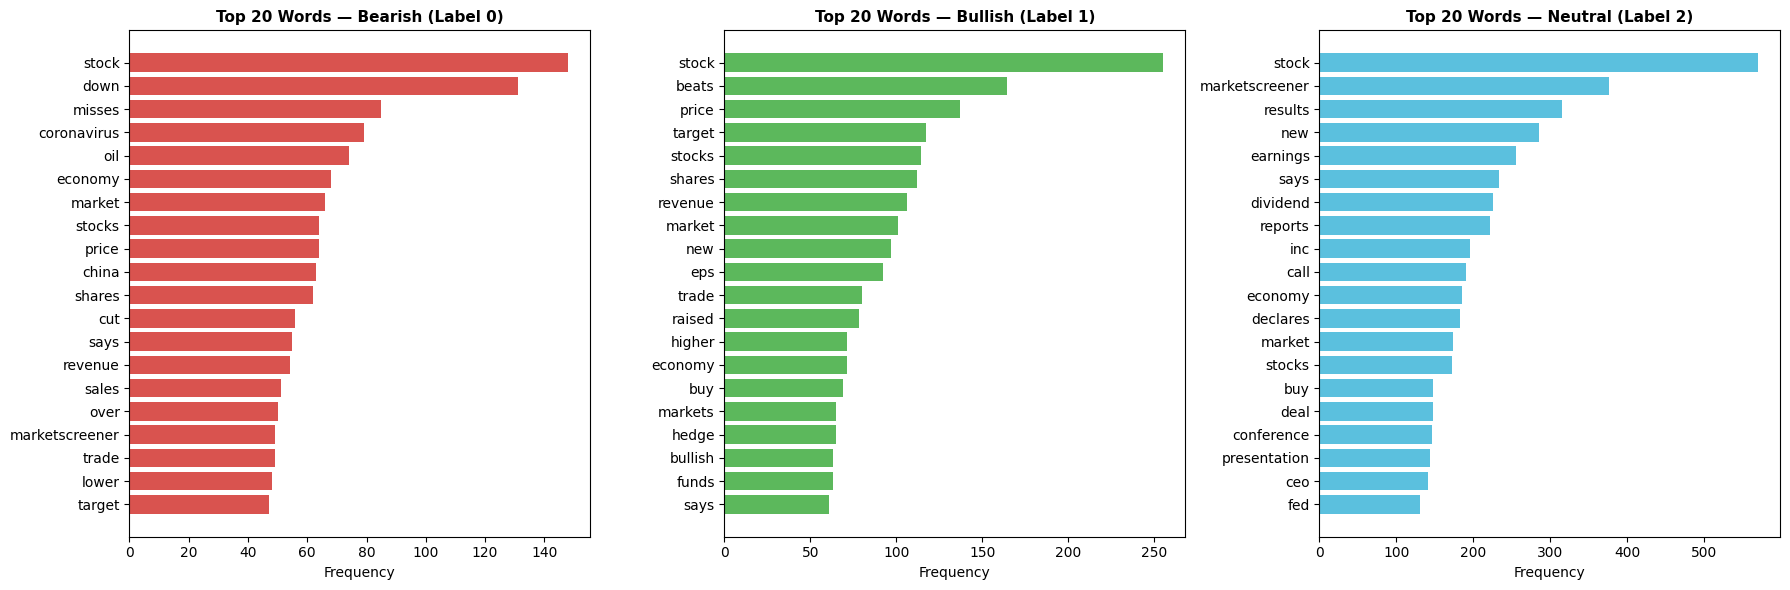

✓ Plot saved to assets/top_words_per_class.png


In [9]:
# Top Frequent Words Per Class
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Keep financially meaningful words that NLTK stopwords would remove
keep_words = {'up', 'down', 'not', 'no', 'nor', 'against', 'below', 'above', 'under', 'over'}
stop_words = stop_words - keep_words

def get_top_words(df, label_id, n=20):
    texts = df[df['label'] == label_id]['text'].tolist()
    words = []
    for text in texts:
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'\$\w+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        tokens = text.lower().split()
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

bearish_words = get_top_words(train, 0)
bullish_words = get_top_words(train, 1)
neutral_words = get_top_words(train, 2)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, words, title, color in zip(
    axes,
    [bearish_words, bullish_words, neutral_words],
    ['Bearish (Label 0)', 'Bullish (Label 1)', 'Neutral (Label 2)'],
    ['#d9534f', '#5cb85c', '#5bc0de']
):
    labels_w = [w[0] for w in words]
    counts   = [w[1] for w in words]
    ax.barh(labels_w[::-1], counts[::-1], color=color)
    ax.set_title(f'Top 20 Words — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../assets/top_words_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/top_words_per_class.png")

Top 10 Tickers — Bearish:
  $USO       : 7
  $NFLX      : 4
  $UBER      : 4
  $OIL       : 4
  $LK        : 3
  $GME       : 3
  $ECONX     : 3
  $SCANX     : 3
  $ZM        : 3
  $ESS       : 2

Top 10 Tickers — Bullish:
  $TSLA      : 9
  $SPY       : 8
  $SCANX     : 7
  $NVDA      : 6
  $SUMRX     : 6
  $INPX      : 6
  $ECONX     : 5
  $LYFT      : 4
  $AAPL      : 4
  $DIS       : 4

Top 10 Tickers — Neutral:
  $COMDX     : 21
  $SPY       : 16
  $TSLA      : 9
  $WIRES     : 9
  $ULTA      : 8
  $MDCO      : 8
  $BONDX     : 7
  $QQQ       : 7
  $SUMRX     : 6
  $IWM       : 6


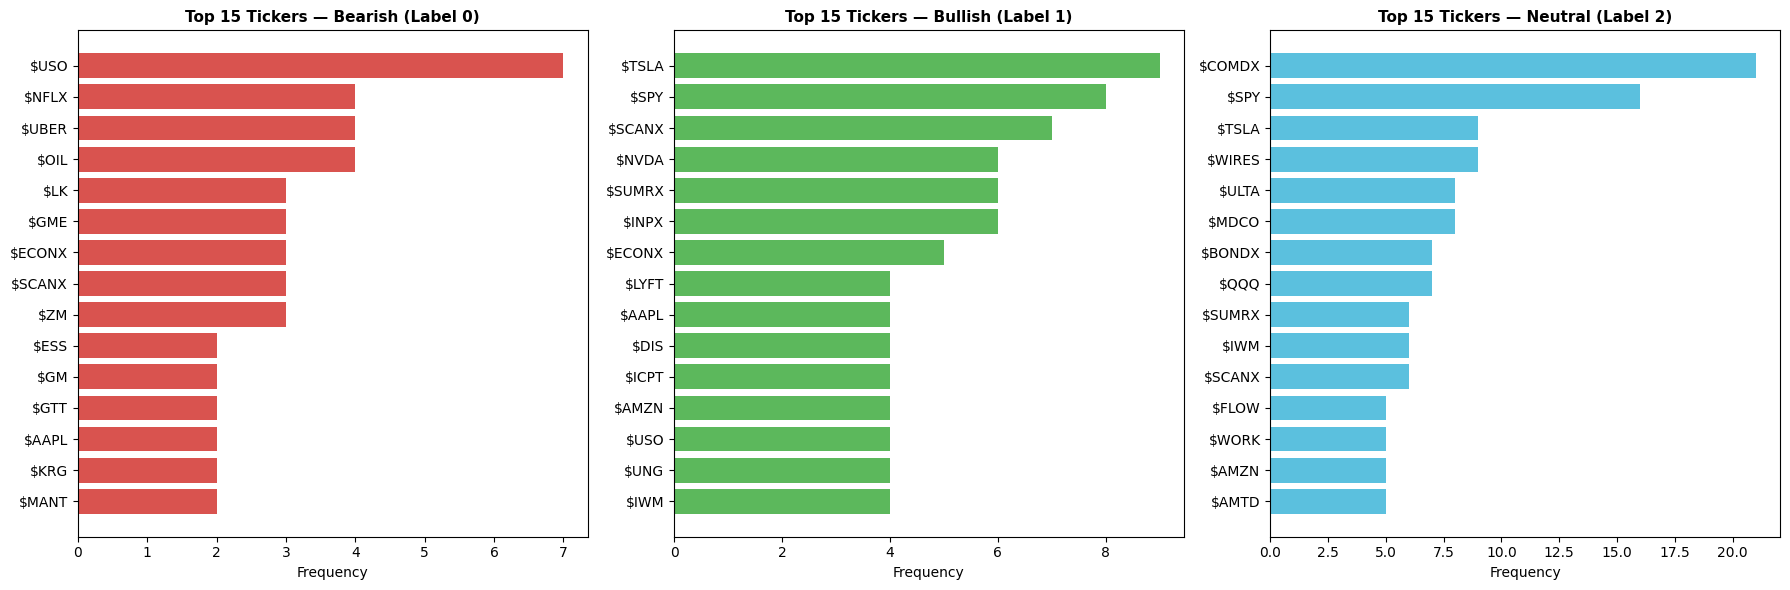

✓ Plot saved to assets/top_tickers_per_class.png


In [10]:
# Top Tickers Analysis
def extract_tickers(df, label_id):
    texts = df[df['label'] == label_id]['text'].tolist()
    tickers = []
    for text in texts:
        found = re.findall(r'\$[A-Z]{1,5}', text)
        tickers.extend(found)
    return Counter(tickers).most_common(15)

bearish_tickers = extract_tickers(train, 0)
bullish_tickers = extract_tickers(train, 1)
neutral_tickers = extract_tickers(train, 2)

print("Top 10 Tickers — Bearish:")
for t, c in bearish_tickers[:10]:
    print(f"  {t:<10} : {c}")

print()
print("Top 10 Tickers — Bullish:")
for t, c in bullish_tickers[:10]:
    print(f"  {t:<10} : {c}")

print()
print("Top 10 Tickers — Neutral:")
for t, c in neutral_tickers[:10]:
    print(f"  {t:<10} : {c}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, tickers, title, color in zip(
    axes,
    [bearish_tickers, bullish_tickers, neutral_tickers],
    ['Bearish (Label 0)', 'Bullish (Label 1)', 'Neutral (Label 2)'],
    ['#d9534f', '#5cb85c', '#5bc0de']
):
    labels_t = [t[0] for t in tickers]
    counts   = [t[1] for t in tickers]
    ax.barh(labels_t[::-1], counts[::-1], color=color)
    ax.set_title(f'Top 15 Tickers — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../assets/top_tickers_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to assets/top_tickers_per_class.png")

In [13]:
# EDA Summary
print("=" * 60)
print("         EDA SUMMARY — Financial News Sentiment")
print("=" * 60)

print(f"""
DATASET
  Train samples        : {len(train):,}
  Validation samples   : {len(valid):,}
  Total                : {len(train) + len(valid):,}
  Columns              : text, label
  Null values          : None
  Duplicates           : None
  Data leakage         : None

CLASS DISTRIBUTION (Train)
  Bearish  (0)         : {train[train['label']==0].shape[0]:,}  (15.1%)
  Bullish  (1)         : {train[train['label']==1].shape[0]:,}  (20.2%)
  Neutral  (2)         : {train[train['label']==2].shape[0]:,}  (64.7%)
  Imbalance ratio      : 4.3x (Neutral vs Bearish)

TWEET LENGTH (Train)
  Min word count       : {train['word_count'].min()}
  Max word count       : {train['word_count'].max()}
  Mean word count      : {train['word_count'].mean():.1f}
  Median word count    : {train['word_count'].median():.0f}
  95th percentile      : {train['word_count'].quantile(0.95):.0f}

PREPROCESSING DECISIONS (Carry to Phase 2)
  MAX_SEQUENCE_LENGTH  : 32   (covers 100% of train data)
  MAX_TOKEN_LENGTH     : 64   (for BERT tokenizer)
  Remove               : URLs, @mentions, special characters
  Keep                 : $TICKERS, directional words (up/down/not)
  Stopwords            : NLTK minus financial signal words
  Imbalance fix        : class_weight in CrossEntropyLoss

KEY INSIGHT
  'stock','market','price' appear in ALL 3 classes.
  Sentiment is carried by CONTEXT, not individual keywords.
  LSTM and BERT required to capture contextual meaning.
""")

print("  Phase 1 — EDA COMPLETE")


         EDA SUMMARY — Financial News Sentiment

DATASET
  Train samples        : 9,543
  Validation samples   : 2,388
  Total                : 11,931
  Columns              : text, label
  Null values          : None
  Duplicates           : None
  Data leakage         : None

CLASS DISTRIBUTION (Train)
  Bearish  (0)         : 1,442  (15.1%)
  Bullish  (1)         : 1,923  (20.2%)
  Neutral  (2)         : 6,178  (64.7%)
  Imbalance ratio      : 4.3x (Neutral vs Bearish)

TWEET LENGTH (Train)
  Min word count       : 1
  Max word count       : 32
  Mean word count      : 12.2
  Median word count    : 11
  95th percentile      : 21

PREPROCESSING DECISIONS (Carry to Phase 2)
  MAX_SEQUENCE_LENGTH  : 32   (covers 100% of train data)
  MAX_TOKEN_LENGTH     : 64   (for BERT tokenizer)
  Remove               : URLs, @mentions, special characters
  Keep                 : $TICKERS, directional words (up/down/not)
  Stopwords            : NLTK minus financial signal words
  Imbalance fix     